# P3HO₄–enzyme candidate binding modes

Independent research follow-up to `enzyme_pha_analysis.ipynb` (whose last numbered figure is **Figure 6**). Run this notebook in **ipha_clean**. It loads the existing energy and all-residue distance CSVs; it does not run the earlier notebook or rewrite its results. Figures **7** and **8** are exported separately for ANC45 and GK13, as 400 dpi PNGs. Matplotlib defaults, blue/orange colours, red dashed energy means, 8 × 4.5 inch panels, labels and border/grid styling follow the working notebook.

ANC45 candidate A is approximately 0–270 ns and B 350–800 ns. The initial equal comparisons are **100–200 ns** and **400–500 ns**. These are hypotheses about binding modes, not confirmed states. Both intervals contain changing contacts. Confirm geometries and persistence before assigning modes.

GK13 has its own evidence-based windows below. Window selection uses saved distances/contacts, **not energy differences**. Whole-system total energy includes enzyme, polymer, solvent and ions: its mean, fluctuations and drift are useful diagnostics, but **cannot establish binding affinity or rank the thermodynamic stability of these modes**. Absolute energies of different systems are not comparable here.

All paths, windows, selections and the **3.5 Å** cutoff are in one configuration cell. Default outputs go to a fresh `analysis/binding_modes/<RUN_ID>/` within each system. Rerunning the configuration creates a fresh run; an existing run directory is protected. To execute elsewhere, set `BINDING_MODES_OUTPUT_ROOT` (only the output location changes). Source CSVs are checked against saved provenance before use. Missing compatible residue caches may be computed **only for selected windows and their bracketing samples**; an invalid existing cache raises an error rather than being silently replaced. MDAnalysis/GROMACS are needed only for the respective fallback calculations.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import os, json, hashlib, subprocess, shutil, tempfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# EDIT HERE: all scientific configuration and input/output locations.
BASE_DIR = Path('/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme')
SYSTEM_CONFIG = {
    'ANC45_P3HO4': {'folder': 'ANC45_P3HO_4_gromacs',
                    'windows': {'A': (100.0, 200.0), 'B': (400.0, 500.0)}},
    'GK13_P3HO4': {'folder': 'GK13_P3HO_4_gromacs',
                   'windows': {'A': (250.0, 350.0), 'B': (500.0, 600.0)}},
}
CONTACT_CUTOFF_A = 3.5
SOURCE_TAG = 'research_0_1000ns'
TPR_NAME = 'step7_production.tpr'
TRAJECTORY_NAME = 'processed_protein_centered.xtc'
EDR_NAME = 'production_combined_1us.edr'
PROTEIN_SELECTION, PHA_SELECTION = 'protein', 'resname LIG'
ALLOW_MISSING_RESIDUE_CALCULATION = True
GMX = shutil.which('gmx') or 'gmx'
DISTANCE_TOLERANCE_A = 2e-5
BLOCK_NS = 10.0
BLOCK_SENSITIVITY_NS = (5.0, 10.0, 20.0)
BOOTSTRAP_REPEATS, RANDOM_SEED = 10000, 20261005
TOP_N, PROMINENT_PERCENT = 10, 10.0  # Union of top N nonzero and >=10% in either window.
GK13_SCAN_BIN_NS = 50.0
FIGSIZE, PNG_DPI = (8, 4.5), 400
WINDOW_COLOURS = {'A': 'tab:blue', 'B': 'tab:orange'}
SAVE_RESULTS = True
RUN_ID = os.environ.get('BINDING_MODES_RUN_ID') or datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
OUTPUT_ROOT = Path(os.environ['BINDING_MODES_OUTPUT_ROOT']) if os.environ.get('BINDING_MODES_OUTPUT_ROOT') else None

plt.rcdefaults()
plt.rcParams.update({'figure.figsize': FIGSIZE, 'savefig.dpi': PNG_DPI,
                     'axes.spines.left': True, 'axes.spines.bottom': True,
                     'axes.spines.top': False, 'axes.spines.right': False})
for name, cfg in SYSTEM_CONFIG.items():
    if set(cfg['windows']) != {'A', 'B'}:
        raise ValueError(f'{name}: supply A and B windows')
    a, b = cfg['windows']['A'], cfg['windows']['B']
    if any(not np.isfinite(w).all() or w[0] < 0 or w[1] <= w[0] for w in (a,b)) or a[1] > b[0]:
        raise ValueError('Require ordered non-overlapping finite windows')
    if not np.isclose(a[1]-a[0], b[1]-b[0]):
        raise ValueError('Use equal duration windows for the initial comparison')
if not np.isfinite(CONTACT_CUTOFF_A) or CONTACT_CUTOFF_A <= 0:
    raise ValueError('Cutoff must be positive finite Å')
if BLOCK_NS <= 0 or BOOTSTRAP_REPEATS < 1000 or min(BLOCK_SENSITIVITY_NS) <= 0:
    raise ValueError('Invalid block/bootstrap settings')
print('Run:', RUN_ID, '| cutoff:', CONTACT_CUTOFF_A, 'Å')
display(pd.DataFrame([{'system':s, 'window':label, 'start_ns':w[0], 'end_ns':w[1]}
                      for s,c in SYSTEM_CONFIG.items() for label,w in c['windows'].items()]))

Run: 20261005_p3ho4_candidate_modes | cutoff: 3.5 Å


,system,window,start_ns,end_ns
0,ANC45_P3HO4,A,100.0,200.0
1,ANC45_P3HO4,B,400.0,500.0
2,GK13_P3HO4,A,250.0,350.0
3,GK13_P3HO4,B,500.0,600.0


### Definitions, coverage and uncertainty

Distances are **minimum heavy-atom distances using the frame's original periodic box**, without fitting or coordinate transformations. Heavy atoms follow the working notebook's TPR **mass >3 u** rule; enzyme selection `protein`, PHA `resname LIG`. A global minimum-distance CSV cannot recover all contacting residues: the wide residue-distance CSV and its residue identity table are required.

Residue occupancy is **100 × time when any heavy atom of that residue is ≤3.5 Å from any PHA heavy atom / selected elapsed time**. Separation remains in the denominator. We reuse the tested notebook's actual-time weighting and linear interpolation of cutoff crossings. Window boundaries are interpolated only when bracketed by real samples, never extrapolated. No smoothing enters calculations. Distributions are weighted by timestamp midpoint cells. Mean energy and distance use trapezoidal integration; energy variability is the time-weighted SD (not uncertainty of the mean). Drift is the descriptive slope of equal-duration block means.

Uncertainty intervals resample **whole non-overlapping time blocks**, not individual frames: default 10 ns, with 5/10/20 ns sensitivity. Each block statistic integrates its actual timestamps; blocks are resampled jointly across residues. Reported 95% intervals are **conditional block-bootstrap intervals within one selected trajectory window**, assuming sufficient decorrelation and approximate stationarity at the chosen block length. Block lag-one correlations and few-block warnings are saved. Persistent correlations, drift, transitions and data-selected windows can make these intervals optimistic; they are not independent-replicate confidence intervals. No p-values, significance labels, free energies or stability ranking are produced. Absence of observed contacts is not proof of zero probability.

In [2]:
def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda: f.read(1024*1024), b''): h.update(chunk)
    return h.hexdigest()

def file_record(path, digest=False):
    path = Path(path); stat = path.stat()
    result = {'path': str(path.resolve()), 'size':stat.st_size, 'mtime_ns':stat.st_mtime_ns}
    if digest: result['sha256'] = sha256(path)
    return result

def validate_times(times):
    t = np.asarray(times, float)
    if t.ndim != 1 or len(t) < 2 or not np.isfinite(t).all() or np.any(np.diff(t) <= 0):
        raise ValueError('Need finite strictly increasing times, with at least two samples')
    return t

def clip_series(times, values, start, end):
    t = validate_times(times); v = np.asarray(values, float)
    if v.shape[0] != len(t) or not np.isfinite(v).all() or not t[0] <= start < end <= t[-1]:
        raise ValueError('Invalid data or requested window outside real sampled coverage')
    inner = (t > start) & (t < end)
    matrix = v.reshape(len(t), -1)
    out = np.vstack(([np.interp(start,t,col) for col in matrix.T], matrix[inner],
                     [np.interp(end,t,col) for col in matrix.T]))
    return np.r_[start,t[inner],end], out.reshape((len(out),)+v.shape[1:])

def contact_duration(times, distances, cutoff):
    t = validate_times(times); d = np.asarray(distances, float)
    if d.shape[0] != len(t) or not np.isfinite(d).all() or np.any(d < 0) or not np.isfinite(cutoff) or cutoff <= 0:
        raise ValueError('Invalid distances or cutoff')
    left,right = d[:-1],d[1:]; il,ir = left<=cutoff,right<=cutoff
    fraction = (il & ir).astype(float); crossing = il != ir
    f = (cutoff-left[crossing])/(right[crossing]-left[crossing])
    fraction[crossing] = np.where(il[crossing],f,1-f)
    dt = np.diff(t).reshape((-1,)+(1,)*(d.ndim-1))
    return np.sum(dt*np.clip(fraction,0,1),axis=0)

def time_mean(times, values):
    t=validate_times(times);v=np.asarray(values,float)
    if v.shape[0]!=len(t) or not np.isfinite(v).all():raise ValueError('Invalid time-mean data')
    dt=np.diff(t).reshape((-1,)+(1,)*(v.ndim-1))
    return np.sum(dt*(v[:-1]+v[1:])/2,axis=0)/(t[-1]-t[0])

def midpoint_weights(times):
    t = validate_times(times)
    return np.diff(np.r_[t[0],(t[:-1]+t[1:])/2,t[-1]])/(t[-1]-t[0])

def block_values(t, v, block_ns, contact=False):
    duration=t[-1]-t[0]; n=int(round(duration/block_ns))
    if n < 3 or not np.isclose(n*block_ns,duration,atol=1e-8,rtol=0):
        raise ValueError('Block length must divide window duration into at least three equal blocks')
    edges=np.linspace(t[0],t[-1],n+1); stats=[]
    for start,end in zip(edges[:-1],edges[1:]):
        bt,bv=clip_series(t,v,start,end)
        stats.append(100*contact_duration(bt,bv,CONTACT_CUTOFF_A)/(end-start) if contact else time_mean(bt,bv))
    return (edges[:-1]+edges[1:])/2, np.asarray(stats)

def block_interval(stats, seed=RANDOM_SEED):
    stats=np.asarray(stats); n=len(stats)
    # Multinomial counts are exactly bootstrap resampling of entire blocks.
    weights=np.random.default_rng(seed).multinomial(n,np.full(n,1/n),size=BOOTSTRAP_REPEATS)/n
    draws=weights @ stats
    return np.percentile(draws,[2.5,97.5],axis=0)

def lag_one(values):
    v=np.asarray(values,float)
    if len(v)<3 or np.std(v[:-1])<1e-12 or np.std(v[1:])<1e-12: return np.nan
    return float(np.corrcoef(v[:-1],v[1:])[0,1])

def coverage_record(data,start,end):
    q=data.loc[data.time_ns.between(start,end)]; t=q.time_ns.to_numpy()
    if len(t)<2: raise ValueError('Too few actual samples inside window')
    dt=np.diff(t)
    return {'requested_start_ns':start,'requested_end_ns':end,'actual_first_sample_ns':float(t[0]),
            'actual_last_sample_ns':float(t[-1]),'actual_sample_count':len(t),
            'interval_min_ns':float(dt.min()),'interval_max_ns':float(dt.max()),
            'uniform_sampling':bool(np.allclose(dt,dt[0],atol=1e-8,rtol=0)),
            'interpolated_start':not bool(np.isclose(t,start,atol=1e-8,rtol=0).any()),
            'interpolated_end':not bool(np.isclose(t,end,atol=1e-8,rtol=0).any())}

def source_paths(cfg):
    folder=BASE_DIR/cfg['folder']; p=folder/'analysis'/f"{cfg['folder'].removesuffix('_gromacs')}_{SOURCE_TAG}"
    return {'tpr':folder/TPR_NAME,'xtc':folder/'analysis'/TRAJECTORY_NAME,'edr':folder/EDR_NAME,
            'energy':Path(f'{p}_total_energy.csv'),'global':Path(f'{p}_enzyme_pha_min_distance.csv'),
            'summary':Path(f'{p}_summary.json'),'distances':Path(f'{p}_residue_pha_distances_A.csv'),
            'residues':Path(f'{p}_residue_pha_residues.csv'),'metadata':Path(f'{p}_residue_pha_metadata.json'),
            'snapshots':Path(f'{p}_residue_pha_snapshots_by_200ns_3p5A.csv')}

def check_raw_provenance(paths,meta):
    for key in ('tpr','xtc'):
        if paths[key].resolve()!=Path(meta['inputs'][key]).resolve(): raise ValueError('Source path changed')
        rec=file_record(paths[key])
        if [rec['size'],rec['mtime_ns']]!=meta['input_size_mtime_ns'][key]:
            raise ValueError(f'{key}: source differs from saved provenance')

def check_distances(d,residues,global_data):
    cols=residues.distance_column.tolist()
    if d.columns.tolist()!=['frame','time_ns']+cols or len(cols)!=len(set(cols)) or residues.resindex.duplicated().any():
        raise ValueError('Residue identifiers do not match distance schema')
    validate_times(d.time_ns)
    if not np.isfinite(d[cols]).all().all() or (d[cols]<0).any().any(): raise ValueError('Invalid distances')
    g=global_data.set_index('frame').loc[d.frame]
    if not np.allclose(g.time_ns,d.time_ns,atol=1e-8,rtol=0) or not np.allclose(g.enzyme_pha_min_distance_A,d[cols].min(axis=1),atol=DISTANCE_TOLERANCE_A,rtol=0):
        raise ValueError('All-residue minima do not reproduce global distances/frames')

def required_frames(global_data,windows):
    # Include only each selected interval and its nearest boundary bracketing samples.
    t=global_data.time_ns.to_numpy(); keep=np.zeros(len(t),bool)
    for start,end in windows.values():
        if not t[0]<=start<end<=t[-1]: raise ValueError('Window outside saved trajectory coverage')
        lo=max(0,np.searchsorted(t,start,side='right')-1)
        hi=min(len(t)-1,np.searchsorted(t,end,side='left'))
        keep[lo:hi+1]=True
    return global_data.loc[keep,['frame','time_ns']].copy()

def calculate_selected_residues(paths,global_data,summary,windows):
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import distance_array
    from MDAnalysis.lib.mdamath import triclinic_vectors
    samples=required_frames(global_data,windows); before={k:file_record(paths[k]) for k in ('tpr','xtc')}
    # Temporary symlink keeps XTC offset sidecars away from the original data.
    with tempfile.TemporaryDirectory(prefix='ipha_binding_residues_') as scratch:
        link=Path(scratch)/'trajectory.xtc';link.symlink_to(paths['xtc'])
        u=mda.Universe(str(paths['tpr']),str(link))
        try:
            protein=u.select_atoms(PROTEIN_SELECTION); pha=u.select_atoms(PHA_SELECTION)
            heavy=protein[protein.masses>3]; ligand=pha[pha.masses>3]
            counts={'system_atoms':len(u.atoms),'protein_atoms':len(protein),'protein_residues':len(protein.residues),
                    'protein_heavy_atoms':len(heavy),'pha_atoms':len(pha),'pha_heavy_atoms':len(ligand)}
            identity=[{'resid':int(r.resid),'resname':str(r.resname),'segid':str(r.segid)} for r in pha.residues]
            if any(n!=summary['counts'][k] for k,n in counts.items()) or identity!=summary['counts']['pha_identity']:
                raise ValueError('Selections differ from validated global results')
            if len(u.atoms)!=u.trajectory.n_atoms or len(protein.fragments)!=1 or np.intersect1d(heavy.indices,ligand.indices).size:
                raise ValueError('Topology/trajectory or atom selections incompatible')
            indices,starts=np.unique(heavy.resindices,return_index=True)
            if np.any(np.diff(heavy.resindices)<0) or not np.array_equal(indices,protein.residues.resindices):
                raise ValueError('Missing or unordered residue heavy atoms')
            rows=[]
            for i in indices:
                r=u.residues[i]; atoms=heavy[heavy.resindices==i]
                rows.append({'distance_column':f'resindex_{i}_{r.resname}{r.resid}_A','resindex':int(i),
                             'resid':int(r.resid),'resname':str(r.resname),'segid':str(r.segid),
                             'heavy_atom_count':len(atoms),'heavy_atom_names':' '.join(atoms.names)})
            residues=pd.DataFrame(rows); values=[]
            for row in samples.itertuples(index=False):
                ts=u.trajectory[int(row.frame)];box=ts.dimensions
                if not np.isclose(ts.time/1000,row.time_ns,atol=1e-8,rtol=0):raise ValueError('Frame/time mismatch')
                if box is None or not np.isfinite(box).all() or np.any(box[:3]<=0) or np.linalg.det(triclinic_vectors(box))<=0:
                    raise ValueError('Invalid periodic box')
                xyz=heavy.positions.copy(); ligxyz=ligand.positions.copy()
                if not np.isfinite(xyz).all() or not np.isfinite(ligxyz).all():raise ValueError('Nonfinite coordinates')
                values.append(np.minimum.reduceat(distance_array(xyz,ligxyz,box=box).min(axis=1),starts))
        finally: u.trajectory.close()
    if before!={k:file_record(paths[k]) for k in ('tpr','xtc')}: raise RuntimeError('Input changed during calculation')
    result=pd.concat([samples.reset_index(drop=True),pd.DataFrame(values,columns=residues.distance_column)],axis=1)
    check_distances(result,residues,global_data)
    return result,residues,{'mode':'computed selected frames only','frames_read':len(samples),
                          'MDAnalysis_version':mda.__version__,'counts':counts,'input_records':before}

def load_energy(paths,windows):
    if paths['energy'].exists():
        return pd.read_csv(paths['energy'],usecols=['time_ns','total_energy_kj_mol']), {'mode':'saved CSV','source':str(paths['energy'])}
    parts=[]; logs=[]
    for label,(start,end) in windows.items():
        with tempfile.TemporaryDirectory(prefix='ipha_binding_energy_') as scratch:
            target=Path(scratch)/'energy.xvg'
            cmd=[GMX,'energy','-f',str(paths['edr']),'-o',str(target),'-dp','-xvg','none',
                 '-b',str(start*1000),'-e',str(end*1000)]
            r=subprocess.run(cmd,input='Total-Energy\n0\n',text=True,capture_output=True,cwd=scratch)
            if r.returncode:raise RuntimeError(r.stderr)
            arr=np.loadtxt(target,ndmin=2)
            if arr.shape[1]!=2:raise ValueError('Expected exactly Total-Energy plus time')
            parts.append(pd.DataFrame({'time_ns':arr[:,0]/1000,'total_energy_kj_mol':arr[:,1]}))
            logs.append({'window':label,'command':cmd,'stdout':r.stdout,'stderr':r.stderr})
    return pd.concat(parts).drop_duplicates('time_ns').sort_values('time_ns'), {'mode':'selected EDR extraction','logs':logs}

# Analytic checks: uneven intervals, exact cutoff and bracketing boundaries.
assert np.isclose(contact_duration([0,3,10],np.array([2,2,5]),3.5),6.5)
assert contact_duration([0,10],np.array([3.5,3.5]),3.5)==10
assert np.allclose(contact_duration([0,1,2],np.array([[2,5],[5,2],[2,5]]),3.5),[1,1])
assert np.isclose(midpoint_weights([0,3,10]).sum(),1)

### Load and validate existing results
Saved CSV schemas, hashes, source paths, TPR/XTC fingerprints, selections, units, frames and the agreement of residue minima with Figure 3 are checked. Energy EDR fingerprints are checked too. The old energy CSV has no stored hash; its current hash is recorded, but this cannot retroactively prove the original extraction was unmodified. The cache contains validated periodic distances; reading it does not re-execute MDAnalysis.

In [3]:
datasets={}
for name,cfg in SYSTEM_CONFIG.items():
    paths=source_paths(cfg); summary=json.loads(paths['summary'].read_text())
    check_raw_provenance(paths,summary)
    if summary['selections']['protein']!=PROTEIN_SELECTION or summary['selections']['pha']!=PHA_SELECTION or summary['selections']['heavy']!='TPR mass > 3 u':
        raise ValueError('Selections differ from original analysis')
    if summary['units']['minimum_distance']!='Å' or summary['units']['time']!='ns' or summary['units']['energy']!='kJ/mol':
        raise ValueError('Source units differ')
    rec=file_record(paths['edr'])
    if paths['edr'].resolve()!=Path(summary['inputs']['edr']).resolve() or [rec['size'],rec['mtime_ns']]!=summary['input_size_mtime_ns']['edr']:
        raise ValueError('EDR differs from saved source')
    global_data=pd.read_csv(paths['global'],usecols=['frame','time_ns','enzyme_pha_min_distance_A'])
    validate_times(global_data.time_ns)
    if global_data.frame.duplicated().any() or not np.equal(global_data.frame,np.floor(global_data.frame)).all():
        raise ValueError('Invalid frame indices')
    if not np.isfinite(global_data.enzyme_pha_min_distance_A).all() or (global_data.enzyme_pha_min_distance_A<0).any():
        raise ValueError('Invalid global distances')
    cached=[paths[k].exists() for k in ('distances','residues','metadata')]
    if any(cached) and not all(cached):raise ValueError('Incomplete existing residue cache; preserve and inspect it')
    if all(cached):
        meta=json.loads(paths['metadata'].read_text()); check_raw_provenance(paths,meta)
        if meta['system']!=cfg['folder'] or meta['selections']!={'protein':PROTEIN_SELECTION,'pha':PHA_SELECTION,'heavy':'TPR mass > 3 u'} or meta['units']!={'time':'ns','distance':'Å'}:
            raise ValueError('Residue cache settings differ')
        for key,hashkey in [('distances','distance_csv_sha256'),('residues','residue_csv_sha256'),('global','figure3_sha256')]:
            if sha256(paths[key])!=meta[hashkey]:raise ValueError(f'Changed {key} CSV')
        distances=pd.read_csv(paths['distances']);residues=pd.read_csv(paths['residues'],keep_default_na=False)
        if not np.array_equal(distances.frame,global_data.frame):raise ValueError('Cache frames differ')
        residue_mode={'mode':'validated saved all-residue cache','frames_read_from_trajectory':0}
    else:
        if not ALLOW_MISSING_RESIDUE_CALCULATION:raise FileNotFoundError('All-residue cache unavailable')
        distances,residues,residue_mode=calculate_selected_residues(paths,global_data,summary,cfg['windows'])
        meta=None
    check_distances(distances,residues,global_data)
    energy,energy_mode=load_energy(paths,cfg['windows']);validate_times(energy.time_ns)
    if not np.isfinite(energy.total_energy_kj_mol).all():raise ValueError('Nonfinite energy')
    records={k:file_record(p,digest=k not in ('tpr','xtc','edr')) for k,p in paths.items() if p.exists()}
    for label,(start,end) in cfg['windows'].items():
        clip_series(distances.time_ns,distances[residues.distance_column].to_numpy(),start,end)
        clip_series(energy.time_ns,energy.total_energy_kj_mol.to_numpy(),start,end)
    out=(OUTPUT_ROOT/name/RUN_ID if OUTPUT_ROOT else BASE_DIR/cfg['folder']/'analysis'/'binding_modes'/RUN_ID)
    if SAVE_RESULTS:
        if out.exists():raise FileExistsError(f'Existing run protected: {out}')
        out.mkdir(parents=True,exist_ok=False)
    datasets[name]={'paths':paths,'global':global_data,'distances':distances,'residues':residues,
                    'energy':energy,'records':records,'out':out,'residue_mode':residue_mode,'energy_mode':energy_mode,
                    'cache_metadata':meta,'windows':{}}
    print(name, ':', len(residues),'residues;', residue_mode['mode'],';',energy_mode['mode'])

ANC45_P3HO4 : 244 residues; validated saved all-residue cache ; saved CSV


GK13_P3HO4 : 245 residues; validated saved all-residue cache ; saved CSV


### GK13 window-selection evidence

The full saved 0–1000 ns **contact cache** is scanned in 50 ns bins (no trajectory rerun). GK13 A = **250–350 ns** samples the earlier SER170/ASN96/PHE92-associated ensemble. The 450–500 ns bin loses contact (about 47% within 3.5 Å), followed by B = **500–600 ns**, where GLN94 becomes prominent, with LEU19/VAL20 and ASP109/THR108 contacts. The 600–750 ns region includes substantial separation; later rebinding involves other patches (e.g. PHE193/ARG219/TRP200). Thus ANC45's broad state boundaries are inappropriate for GK13.

These are exploratory, data-selected **equal 100 ns comparisons**, not automatically identified metastable states. GK13 B includes ~21% contact-free time and changes within its window; inspect the contact map, sensitivity to shifted windows and structures before assigning a distinct binding mode. The table generated below records the evidence with actual values and source path. If configuration changes, use the regenerated table and conclusions rather than the numerical examples here. If only a selected-window fallback cache exists, a full scan is explicitly skipped.

In [4]:
scan_tables={}
for name,item in datasets.items():
    if not name.startswith('GK13'):continue
    d=item['distances'];r=item['residues'];t=d.time_ns.to_numpy();v=d[r.distance_column].to_numpy();rows=[]
    for start in np.arange(0,1000,GK13_SCAN_BIN_NS):
        end=start+GK13_SCAN_BIN_NS
        actual=t[(t>=start)&(t<=end)]
        if t[0]>start or t[-1]<end or len(actual)<2 or np.max(np.diff(actual))>0.100001:
            continue  # Never interpolate through the gap in a selected-window fallback cache.
        bt,bv=clip_series(t,v,start,end); occ=100*contact_duration(bt,bv,CONTACT_CUTOFF_A)/(end-start)
        rank=np.lexsort((r.resindex.to_numpy(),-occ))[:5];minimum=bv.min(axis=1)
        rows.append({'start_ns':start,'end_ns':end,'global_percent_within':100*contact_duration(bt,minimum,CONTACT_CUTOFF_A)/(end-start),
                     'minimum_distance_median_A':float(np.median(minimum)),
                     'leading_residues':'; '.join(f'{r.resname.iloc[i]}{r.resid.iloc[i]} {occ[i]:.2f}%' for i in rank if occ[i]>0),
                     'source_distances':str(item['paths']['distances']),'cutoff_A':CONTACT_CUTOFF_A})
    scan_tables[name]=pd.DataFrame(rows)
    if rows:display(scan_tables[name])
    else:print('Full-window contact scan unavailable; inspect existing window-selection evidence before changing windows.')
    if SAVE_RESULTS:scan_tables[name].to_csv(item['out']/'gk13_window_selection_evidence.csv',index=False)

,start_ns,end_ns,global_percent_within,minimum_distance_median_A,leading_residues,source_distances,cutoff_A
0,0.0,50.0,99.944914,2.770359,ASN96 87.09%; SER48 79.74%; SER139 55.62%; SER...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
1,50.0,100.0,91.861140,3.254862,ASN96 27.43%; SER48 22.96%; LEU173 18.36%; PHE...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
2,100.0,150.0,90.764985,3.304980,PHE49 22.33%; SER48 20.06%; PHE92 18.74%; GLY1...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
3,150.0,200.0,96.241538,3.278825,PHE92 39.25%; ASN96 25.09%; SER170 24.54%; SER...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
4,200.0,250.0,97.367657,3.279710,PHE92 31.27%; ASN96 26.77%; SER139 25.38%; SER...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
5,250.0,300.0,97.254195,3.186192,SER170 52.43%; ASN96 25.85%; SER139 24.27%; PH...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
6,300.0,350.0,95.871872,3.242521,SER170 40.75%; ASN96 26.03%; PHE92 23.99%; SER...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
7,350.0,400.0,96.512837,3.270031,ASN96 36.44%; SER170 25.41%; SER139 18.95%; VA...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
8,400.0,450.0,98.466761,3.265304,SER48 34.05%; PHE92 33.28%; ASN96 23.79%; HSD2...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5
9,450.0,500.0,47.134546,3.532310,PHE49 13.29%; ASN60 8.46%; HSD58 5.94%; LEU1 5...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3.5


### Window summaries and block sensitivity
All residues are retained in the CSV; Figure 8 uses the same union of prominent residues in A and B. Change means **B minus A, in percentage points**, not percent relative change. The exported block statistics allow the uncertainty calculation to be inspected without reopening a trajectory.

In [5]:
for name,item in datasets.items():
    cfg=SYSTEM_CONFIG[name];d=item['distances'];r=item['residues'];e=item['energy']; summaries=[]; sensitivity=[]; block_rows=[]
    occupancy=r.copy(); all_coverage=[]
    for label,(start,end) in cfg['windows'].items():
        t,v=clip_series(d.time_ns,d[r.distance_column].to_numpy(),start,end)
        et,ev=clip_series(e.time_ns,e.total_energy_kj_mol.to_numpy(),start,end)
        # Minimum and then clip the saved global distances, following original Figure 3.
        gt,gv=clip_series(item['global'].time_ns,item['global'].enzyme_pha_min_distance_A.to_numpy(),start,end)
        mean=float(time_mean(et,ev));sd=float(np.sqrt(time_mean(et,(ev-mean)**2)))
        percent=100*contact_duration(t,v,CONTACT_CUTOFF_A)/(end-start)
        global_percent=float(100*contact_duration(gt,gv,CONTACT_CUTOFF_A)/(end-start))
        centers,energy_blocks=block_values(et,ev,BLOCK_NS)
        _,global_blocks=block_values(gt,gv,BLOCK_NS,contact=True)
        _,residue_blocks=block_values(t,v,BLOCK_NS,contact=True)
        eci=block_interval(energy_blocks);gci=block_interval(global_blocks);rci=block_interval(residue_blocks)
        slope,intercept=np.polyfit(centers-(start+end)/2,energy_blocks,1)
        energy_cover=coverage_record(e,start,end);distance_cover=coverage_record(d,start,end)
        all_coverage.extend([{'system':name,'window':label,'metric':'energy',**energy_cover},
                             {'system':name,'window':label,'metric':'residue_distance',**distance_cover}])
        row={'system':name,'window':label,'start_ns':start,'end_ns':end,'duration_ns':end-start,
             'energy_mean_kj_mol':mean,'energy_sd_kj_mol':sd,'energy_mean_block_ci_low_kj_mol':float(eci[0]),
             'energy_mean_block_ci_high_kj_mol':float(eci[1]),'energy_block_mean_drift_kj_mol_ns':float(slope),
             'fitted_energy_change_kj_mol':float(slope*(end-start)),
             'global_distance_time_mean_A':float(time_mean(gt,gv)), 'global_percent_within':global_percent,
             'global_percent_block_ci_low':float(gci[0]),'global_percent_block_ci_high':float(gci[1]),
             'cutoff_A':CONTACT_CUTOFF_A,'block_ns':BLOCK_NS,'block_count':len(centers),
             'energy_block_lag1':lag_one(energy_blocks),'global_contact_block_lag1':lag_one(global_blocks),
             'energy_samples':energy_cover['actual_sample_count'],'distance_samples':distance_cover['actual_sample_count']}
        summaries.append(row)
        occupancy[f'{label}_occupancy_percent']=percent
        occupancy[f'{label}_within_time_ns']=percent*(end-start)/100
        occupancy[f'{label}_ci_low']=rci[0];occupancy[f'{label}_ci_high']=rci[1]
        for bc,eb,gb,rb in zip(centers,energy_blocks,global_blocks,residue_blocks):
            block_rows.append({'window':label,'center_ns':bc,'block_ns':BLOCK_NS,
                               'energy_mean_kj_mol':eb,'global_percent_within':gb,
                               **{col:val for col,val in zip(r.distance_column,rb)}})
        for length in BLOCK_SENSITIVITY_NS:
            _,be=block_values(et,ev,length);_,bg=block_values(gt,gv,length,contact=True)
            _,br=block_values(t,v,length,contact=True);ec=block_interval(be);gc=block_interval(bg);rc=block_interval(br)
            residual_lag=lag_one(be-np.polyval(np.polyfit(np.arange(len(be)),be,1),np.arange(len(be))))
            issues=['single trajectory; stationarity/decorrelation unproven']
            if len(be)<10:issues.append('fewer than 10 blocks')
            if (np.isfinite(residual_lag) and abs(residual_lag)>0.3) or (np.isfinite(lag_one(bg)) and abs(lag_one(bg))>0.3):
                issues.append('appreciable lag-one block correlation')
            for i,res in r.iterrows():
                residue_lag=lag_one(br[:,i])
                residue_issues=issues+(['appreciable residue block correlation'] if np.isfinite(residue_lag) and abs(residue_lag)>0.3 else [])
                sensitivity.append({'window':label,'block_ns':length,'block_count':len(be),
                    'energy_ci_low_kj_mol':ec[0],'energy_ci_high_kj_mol':ec[1],
                    'energy_block_lag1':lag_one(be),'energy_detrended_block_lag1':residual_lag,
                    'global_percent_ci_low':gc[0],'global_percent_ci_high':gc[1],'global_contact_block_lag1':lag_one(bg),
                    'resindex':res.resindex,'resid':res.resid,'resname':res.resname,'segid':res.segid,
                    'residue_occupancy_ci_low':rc[0,i],'residue_occupancy_ci_high':rc[1,i],
                    'residue_contact_block_lag1':residue_lag,'caution':'; '.join(residue_issues)})
        item['windows'][label]={'t':t,'v':v,'energy_t':et,'energy_v':ev,'global_t':gt,'global_v':gv,
                               'block_centers':centers,'energy_blocks':energy_blocks,'summary':row}
    prominent=np.zeros(len(r),bool)
    for label in ('A','B'):
        col=f'{label}_occupancy_percent';prominent|=occupancy[col].to_numpy()>=PROMINENT_PERCENT
        top=occupancy.loc[occupancy[col]>0].sort_values([col,'resindex'],ascending=[False,True]).head(TOP_N).index
        prominent[top]=True
    occupancy['plotted_prominent']=prominent
    occupancy['change_B_minus_A_percentage_points']=occupancy.B_occupancy_percent-occupancy.A_occupancy_percent
    occupancy['cutoff_A']=CONTACT_CUTOFF_A;occupancy['system']=name
    occupancy['definition']='minimum residue/PHA heavy-atom PBC distance <= cutoff; time-weighted linear crossings'
    occupancy['source_distances']=str(item['paths']['distances'])
    item.update({'summary':pd.DataFrame(summaries),'occupancy':occupancy,'coverage':pd.DataFrame(all_coverage),
                 'sensitivity':pd.DataFrame(sensitivity),'blocks':pd.DataFrame(block_rows)})
    if SAVE_RESULTS:
        for key in ('summary','occupancy','coverage','sensitivity','blocks'):
            item[key].to_csv(item['out']/f'{key}.csv',index=False)
        for label,(start,end) in cfg['windows'].items():
            e.loc[e.time_ns.between(start,end)].to_csv(item['out']/f'{label}_energy_samples.csv',index=False)
            d.loc[d.time_ns.between(start,end)].to_csv(item['out']/f'{label}_residue_distance_samples_A.csv',index=False)
            item['global'].loc[item['global'].time_ns.between(start,end)].to_csv(item['out']/f'{label}_global_distance_samples_A.csv',index=False)
        r.to_csv(item['out']/'residue_identifiers.csv',index=False)
    display(Markdown(f'**{name}**'));display(item['summary'].round(3))
    display(occupancy.loc[prominent,['resname','resid','A_occupancy_percent','B_occupancy_percent','change_B_minus_A_percentage_points']].round(2))
    display(item['sensitivity'].drop_duplicates(['window','block_ns'])[['window','block_ns','block_count','energy_detrended_block_lag1','global_contact_block_lag1','caution']])

**ANC45_P3HO4**

,system,window,start_ns,end_ns,duration_ns,energy_mean_kj_mol,energy_sd_kj_mol,energy_mean_block_ci_low_kj_mol,energy_mean_block_ci_high_kj_mol,energy_block_mean_drift_kj_mol_ns,...,global_percent_within,global_percent_block_ci_low,global_percent_block_ci_high,cutoff_A,block_ns,block_count,energy_block_lag1,global_contact_block_lag1,energy_samples,distance_samples
0,ANC45_P3HO4,A,100.0,200.0,100.0,-1553693.122,1894.616,-1553717.989,-1553664.616,-1.049,...,99.560,99.117,100.000,3.5,10.0,10,0.262,0.201,50001,1001
1,ANC45_P3HO4,B,400.0,500.0,100.0,-1553674.683,1889.936,-1553705.407,-1553647.265,0.036,...,98.534,96.960,99.743,3.5,10.0,10,-0.725,-0.023,50001,1001


,resname,resid,A_occupancy_percent,B_occupancy_percent,change_B_minus_A_percentage_points
47,SER,48,14.76,24.97,10.21
49,PHE,50,0.11,18.71,18.60
61,PHE,62,0.45,18.94,18.50
91,TRP,92,10.14,3.04,-7.10
92,GLN,93,8.06,20.01,11.95
93,THR,94,22.09,7.04,-15.05
94,ASN,95,32.06,10.70,-21.36
137,SER,138,26.56,55.65,29.10
138,SER,139,40.15,24.78,-15.37
141,TYR,142,64.45,22.25,-42.20


,window,block_ns,block_count,energy_detrended_block_lag1,global_contact_block_lag1,caution
0,A,5.0,20,-0.238818,0.257067,single trajectory; stationarity/decorrelation ...
244,A,10.0,10,-0.388213,0.201305,single trajectory; stationarity/decorrelation ...
488,A,20.0,5,-0.521631,-0.523696,single trajectory; stationarity/decorrelation ...
732,B,5.0,20,-0.083072,0.185755,single trajectory; stationarity/decorrelation ...
976,B,10.0,10,-0.725306,-0.022620,single trajectory; stationarity/decorrelation ...
1220,B,20.0,5,-0.463001,-0.063600,single trajectory; stationarity/decorrelation ...


**GK13_P3HO4**

,system,window,start_ns,end_ns,duration_ns,energy_mean_kj_mol,energy_sd_kj_mol,energy_mean_block_ci_low_kj_mol,energy_mean_block_ci_high_kj_mol,energy_block_mean_drift_kj_mol_ns,...,global_percent_within,global_percent_block_ci_low,global_percent_block_ci_high,cutoff_A,block_ns,block_count,energy_block_lag1,global_contact_block_lag1,energy_samples,distance_samples
0,GK13_P3HO4,A,250.0,350.0,100.0,-1504830.289,1881.225,-1504869.787,-1504793.581,0.575,...,96.563,94.822,98.041,3.5,10.0,10,-0.043,-0.098,50001,1001
1,GK13_P3HO4,B,500.0,600.0,100.0,-1504908.375,1857.698,-1504951.862,-1504861.447,-1.463,...,78.662,72.799,84.274,3.5,10.0,10,0.247,-0.422,50001,1001


,resname,resid,A_occupancy_percent,B_occupancy_percent,change_B_minus_A_percentage_points
18,LEU,19,0.00,9.76,9.76
19,VAL,20,0.00,8.32,8.32
47,SER,48,9.49,0.01,-9.48
48,PHE,49,14.79,2.94,-11.85
87,PRO,88,0.00,4.18,4.18
90,LEU,91,0.27,4.60,4.33
91,PHE,92,23.62,5.70,-17.91
93,GLN,94,1.36,31.13,29.76
95,ASN,96,25.94,0.32,-25.62
96,ILE,97,9.77,3.61,-6.16


,window,block_ns,block_count,energy_detrended_block_lag1,global_contact_block_lag1,caution
0,A,5.0,20,0.205804,0.425056,single trajectory; stationarity/decorrelation ...
245,A,10.0,10,-0.082419,-0.098086,single trajectory; stationarity/decorrelation ...
490,A,20.0,5,-0.115757,0.105390,single trajectory; stationarity/decorrelation ...
735,B,5.0,20,0.244840,0.201869,single trajectory; stationarity/decorrelation ...
980,B,10.0,10,-0.133433,-0.422109,single trajectory; stationarity/decorrelation ...
1225,B,20.0,5,-0.470320,-0.017679,single trajectory; stationarity/decorrelation ...


### Figure 7 — System energy during the two candidate binding modes
Raw saved samples, dashed window means, shared-bin distributions and block-mean drift. Each window retains its true sampling; the elapsed-time axis is used only to overlay equal-duration windows. SD describes fluctuations; conditional block intervals describe limited within-window uncertainty. No affinity or thermodynamic stability inference follows from these energies.

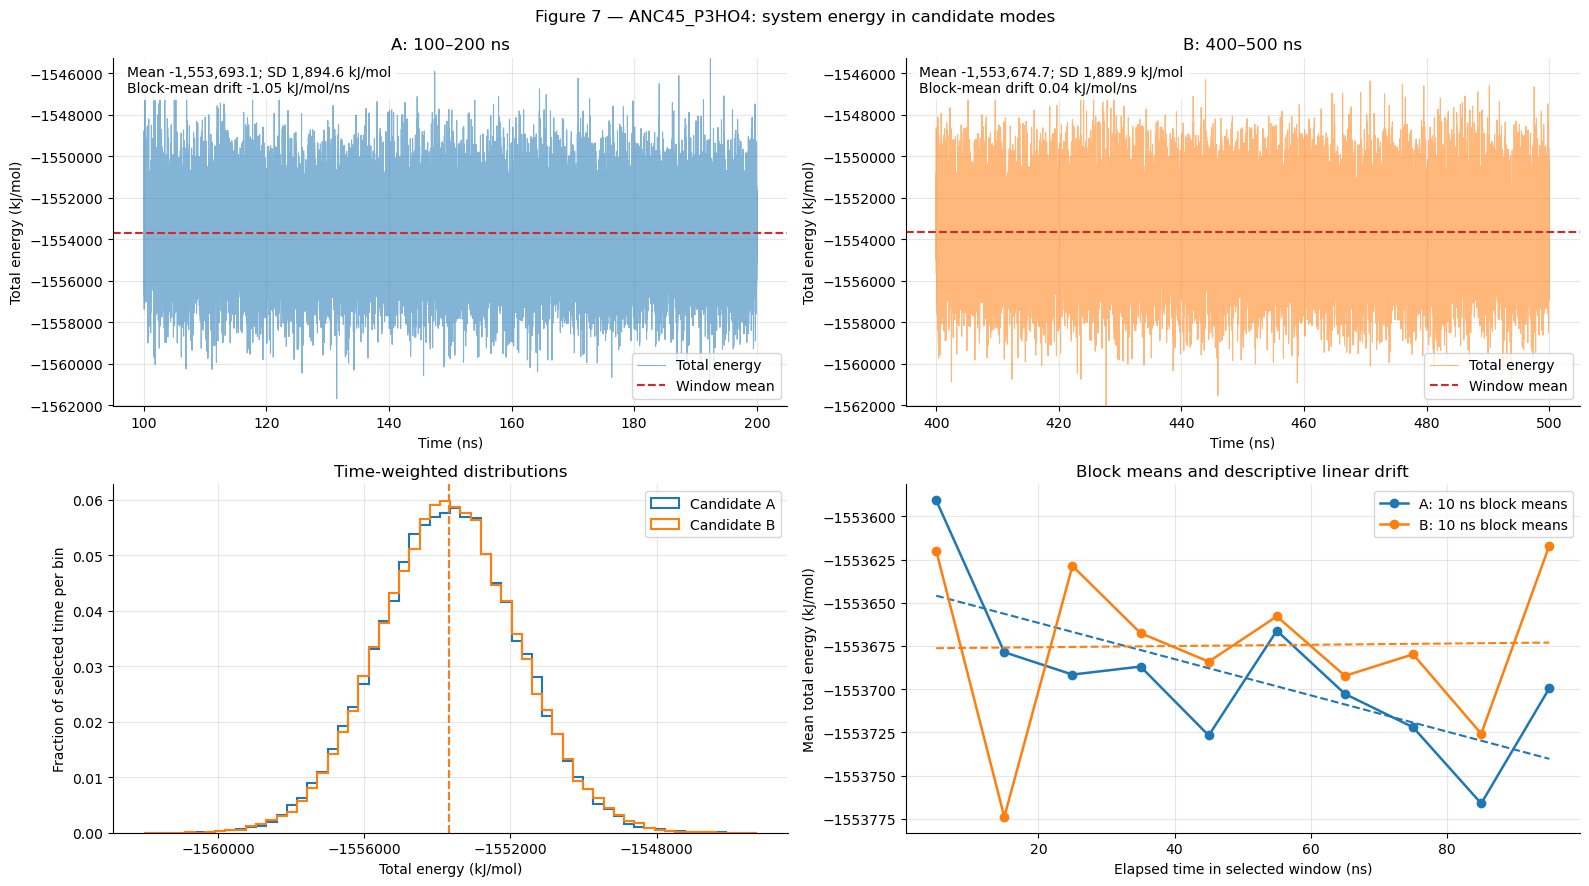

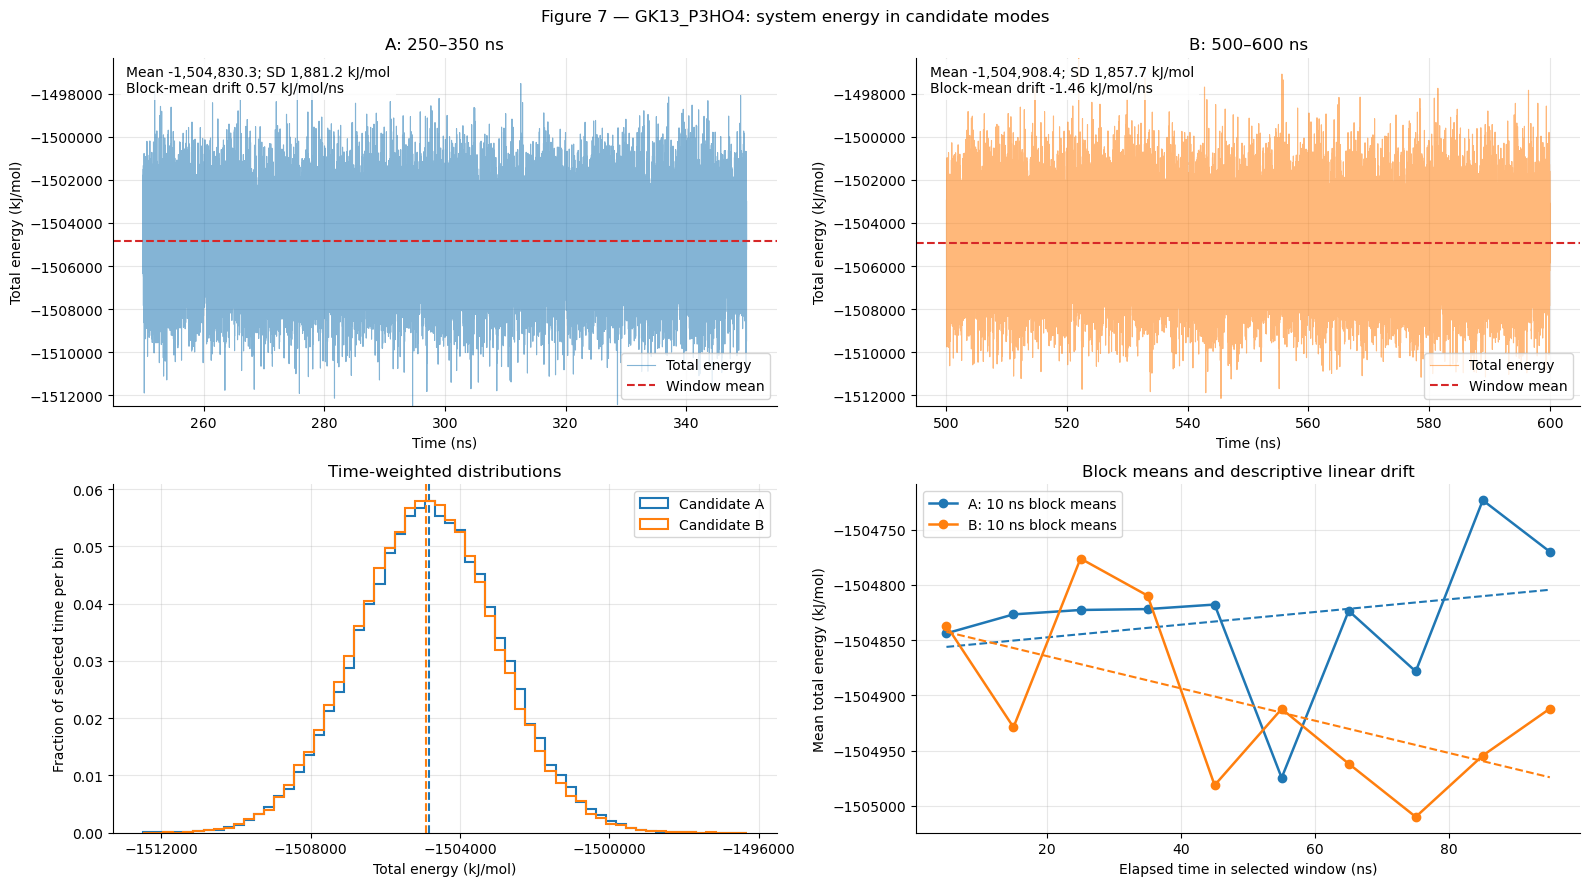

In [6]:
for name,item in datasets.items():
    fig,axes=plt.subplots(2,2,figsize=(2*FIGSIZE[0],2*FIGSIZE[1]))
    all_energy=np.concatenate([w['energy_v'] for w in item['windows'].values()]);bins=np.histogram_bin_edges(all_energy,bins=60)
    for ax,(label,w) in zip(axes[0],item['windows'].items()):
        s=w['summary'];colour=WINDOW_COLOURS[label];t=w['energy_t'];v=w['energy_v']
        ax.plot(t,v,color=colour,lw=0.8,alpha=0.55,label='Total energy')
        ax.axhline(s['energy_mean_kj_mol'],color='tab:red',ls='--',lw=1.5,label='Window mean')
        ax.set(title=f'{label}: {s["start_ns"]:g}–{s["end_ns"]:g} ns',xlabel='Time (ns)',ylabel='Total energy (kJ/mol)',ylim=(all_energy.min(),all_energy.max()))
        ax.text(.02,.98,f'Mean {s["energy_mean_kj_mol"]:,.1f}; SD {s["energy_sd_kj_mol"]:,.1f} kJ/mol\n'
                f'Block-mean drift {s["energy_block_mean_drift_kj_mol_ns"]:.2f} kJ/mol/ns',
                transform=ax.transAxes,va='top',bbox={'facecolor':'white','alpha':.85,'edgecolor':'none'})
        ax.legend(loc='lower right')
        axes[1,0].hist(v,bins=bins,weights=midpoint_weights(t),histtype='step',color=colour,lw=1.5,label=f'Candidate {label}')
        axes[1,0].axvline(s['energy_mean_kj_mol'],color=colour,ls='--',lw=1.5)
        bc=w['block_centers'];elapsed=bc-s['start_ns'];eb=w['energy_blocks']
        axes[1,1].plot(elapsed,eb,'o-',color=colour,lw=1.8,label=f'{label}: {BLOCK_NS:g} ns block means')
        trend=s['energy_mean_kj_mol']+s['energy_block_mean_drift_kj_mol_ns']*(elapsed-s['duration_ns']/2)
        axes[1,1].plot(elapsed,trend,'--',color=colour,lw=1.5)
    axes[1,0].set(xlabel='Total energy (kJ/mol)',ylabel='Fraction of selected time per bin',title='Time-weighted distributions');axes[1,0].legend()
    axes[1,1].set(xlabel='Elapsed time in selected window (ns)',ylabel='Mean total energy (kJ/mol)',title='Block means and descriptive linear drift');axes[1,1].legend()
    for ax in axes.flat:ax.grid(alpha=.3);ax.ticklabel_format(axis='y',style='plain',useOffset=False)
    axes[1,0].ticklabel_format(axis='x',style='plain',useOffset=False)
    axes[1,0].xaxis.set_major_locator(__import__('matplotlib.ticker',fromlist=['MaxNLocator']).MaxNLocator(5))
    fig.suptitle(f'Figure 7 — {name}: system energy in candidate modes')
    fig.tight_layout()
    if SAVE_RESULTS:fig.savefig(item['out']/'figure7_system_energy.png',dpi=PNG_DPI)
    display(fig);plt.close(fig)

### Figure 8 — Enzyme–PHA contacts in the two candidate binding modes
Minimum-distance distributions, global contact-time percentages, residue occupancy and B−A changes. A residue is counted once per time, regardless of atom-pair count. All contact-free time is included. Both windows use the **same union of prominent residues**; full all-residue results are in `occupancy.csv`. Error bars in the global panel are conditional whole-block bootstrap intervals, not tests of significance. The residue changes are descriptive percentage-point differences.

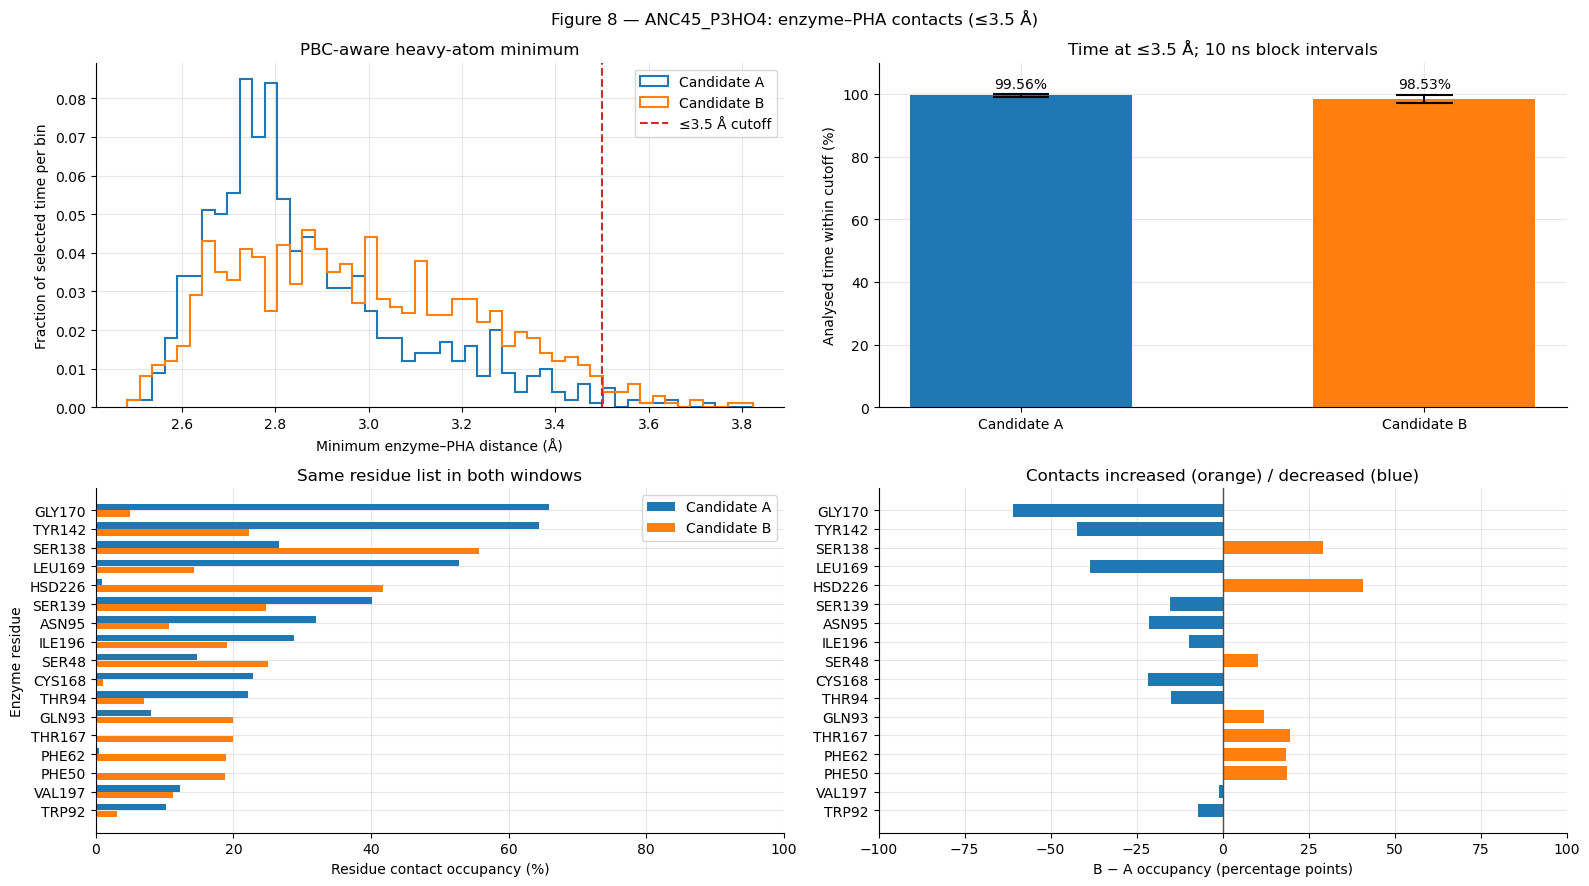

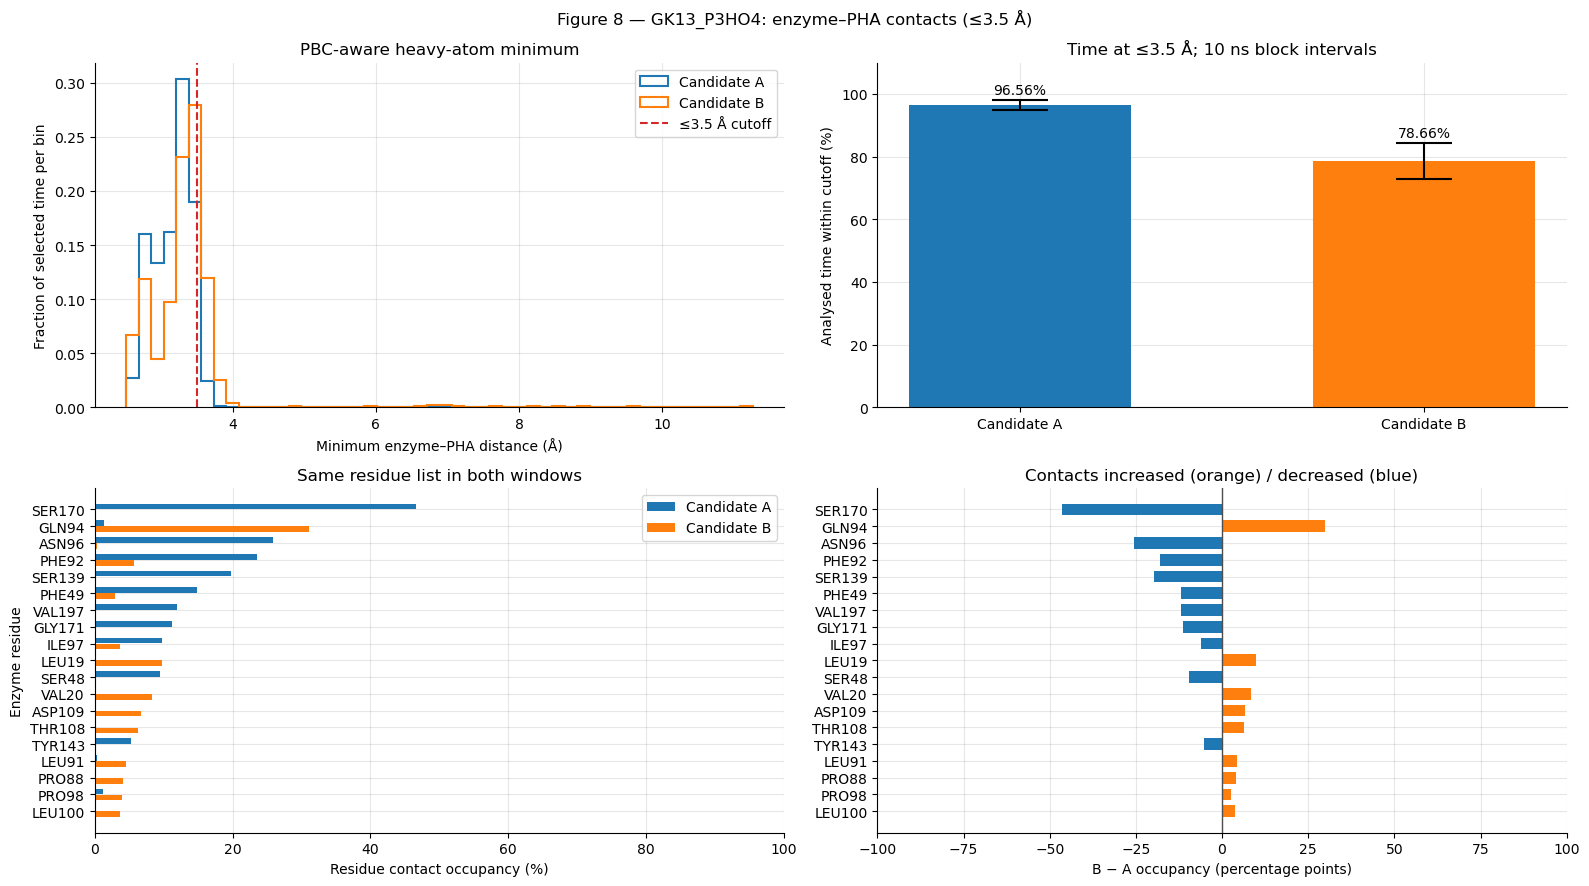

In [7]:
for name,item in datasets.items():
    fig,axes=plt.subplots(2,2,figsize=(2*FIGSIZE[0],2*FIGSIZE[1]))
    all_dist=np.concatenate([w['global_v'] for w in item['windows'].values()]);bins=np.histogram_bin_edges(all_dist,bins=50)
    for j,(label,w) in enumerate(item['windows'].items()):
        s=w['summary'];colour=WINDOW_COLOURS[label]
        axes[0,0].hist(w['global_v'],bins=bins,weights=midpoint_weights(w['global_t']),histtype='step',lw=1.5,color=colour,label=f'Candidate {label}')
        p=s['global_percent_within'];lo=s['global_percent_block_ci_low'];hi=s['global_percent_block_ci_high']
        axes[0,1].bar(j,p,color=colour,width=.55)
        # Bootstrap percentile limits need not bracket the point estimate: draw limits directly.
        axes[0,1].vlines(j,lo,hi,color='black');axes[0,1].hlines([lo,hi],j-.07,j+.07,color='black')
        axes[0,1].text(j,min(105,max(p,hi)+2),f'{p:.2f}%',ha='center')
    axes[0,0].axvline(CONTACT_CUTOFF_A,color='tab:red',ls='--',lw=1.5,label=f'≤{CONTACT_CUTOFF_A:g} Å cutoff')
    axes[0,0].set(xlabel='Minimum enzyme–PHA distance (Å)',ylabel='Fraction of selected time per bin',title='PBC-aware heavy-atom minimum');axes[0,0].legend()
    axes[0,1].set(xticks=[0,1],xticklabels=['Candidate A','Candidate B'],ylabel='Analysed time within cutoff (%)',ylim=(0,110),title=f'Time at ≤{CONTACT_CUTOFF_A:g} Å; {BLOCK_NS:g} ns block intervals')
    table=item['occupancy'].loc[item['occupancy'].plotted_prominent].copy()
    table['max_occupancy']=table[['A_occupancy_percent','B_occupancy_percent']].max(axis=1)
    table=table.sort_values(['max_occupancy','resindex'],ascending=[False,True]);y=np.arange(len(table))
    labels=[f'{x.resname}{int(x.resid)}' for x in table.itertuples()]
    for offset,label in [(-.18,'A'),(.18,'B')]:
        axes[1,0].barh(y+offset,table[f'{label}_occupancy_percent'],height=.34,color=WINDOW_COLOURS[label],label=f'Candidate {label}')
    delta=table.change_B_minus_A_percentage_points.to_numpy()
    axes[1,1].barh(y,delta,color=np.where(delta>=0,'tab:orange','tab:blue'),height=.7)
    for ax in axes[1]:ax.set(yticks=y,yticklabels=labels);ax.invert_yaxis()
    axes[1,0].set(xlabel='Residue contact occupancy (%)',ylabel='Enzyme residue',xlim=(0,100),title='Same residue list in both windows');axes[1,0].legend()
    axes[1,1].axvline(0,color='0.3',lw=1);axes[1,1].set(xlabel='B − A occupancy (percentage points)',title='Contacts increased (orange) / decreased (blue)',xlim=(-100,100))
    for ax in axes.flat:ax.set_axisbelow(True);ax.grid(alpha=.3)
    fig.suptitle(f'Figure 8 — {name}: enzyme–PHA contacts (≤{CONTACT_CUTOFF_A:g} Å)')
    fig.tight_layout()
    if SAVE_RESULTS:
        fig.savefig(item['out']/'figure8_enzyme_pha_contacts.png',dpi=PNG_DPI)
        table.drop(columns='max_occupancy').to_csv(item['out']/'figure8_plotted_residues.csv',index=False)
    display(fig);plt.close(fig)

### Existing structures and interpretation

Reuse the working notebook's already validated standalone PDBs and snapshot table. The cell below lists structures **inside each selected window** and, if none exist, the nearest snapshot explicitly marked **outside the window**. These PDBs were selected as representatives of 200 ns periods, not of these 100 ns comparisons. No new trajectory reading, snapshot export or structural clustering is performed here.

For the initial settings, ANC45 has snapshots at 100.2 ns (SER48 contact) and 496.3 ns (PHE62/SER138/HSD226), consistent with a changed contact pattern but not sufficient by themselves to establish distinct modes. GK13 A contains the 299.8 ns snapshot (SER170); the GLN94 snapshot at 497.3 ns is **outside B = 500–600 ns** and is only neighbouring context. GK13 B still needs an in-window structure assessment. Load the configured TPR and processed XTC in VMD/MDAnalysis, inspect frames within the stated windows with PBC handled, and compare orientation, contact pattern and recurrence. Binding-mode confirmation would require structural analysis and additional sampling beyond these geometric summaries.

The final cell reports results from the editable settings, source fingerprints, actual coverage, intervals, definitions and limitations. Results from one trajectory and data-selected windows are exploratory; energy drift and heterogeneous contacts should prompt further checks, not thermodynamic claims.

In [8]:
for name,item in datasets.items():
    rows=[];p=item['paths']['snapshots']
    if p.exists():
        snapshots=pd.read_csv(p)
        for label,(start,end) in SYSTEM_CONFIG[name]['windows'].items():
            chosen=snapshots.loc[snapshots.time_ns.between(start,end)].copy();inside=not chosen.empty
            if not inside:
                gap=np.maximum(start-snapshots.time_ns,np.maximum(snapshots.time_ns-end,0))
                chosen=snapshots.loc[[gap.idxmin()]].copy()
            for snap in chosen.itertuples(index=False):
                pdb=p.parent/'representative_snapshots'/snap.snapshot_filename
                if not pdb.exists():raise FileNotFoundError(pdb)
                rows.append({'system':name,'window':label,'snapshot_time_ns':snap.time_ns,
                             'inside_comparison_window':inside,'original_period_start_ns':snap.window_start_ns,
                             'original_period_end_ns':snap.window_end_ns,'all_contacting_residues':snap.all_contacting_residues,
                             'pdb_path':str(pdb),'sha256':sha256(pdb),'source_snapshot_table':str(p),
                             'interpretation':'existing 200 ns representative; not selected for this 100 ns comparison'})
    structures=pd.DataFrame(rows);display(structures)
    item['structures']=structures
    if SAVE_RESULTS:structures.to_csv(item['out']/'existing_structure_context.csv',index=False)

for name,item in datasets.items():
    coverage=item['coverage'].to_dict('records')
    warnings_list=['Candidate contact ensembles require structural confirmation',
                   'Whole-system energy cannot establish binding affinity or thermodynamic stability',
                   'Single trajectory, data-selected windows; no independent replicates or significance tests',
                   'Block bootstrap assumes decorrelation/stationarity; sensitivity intervals may be optimistic',
                   'Existing PDBs represent 200 ns periods; no new structures or clustering executed',
                   'Energy source CSV has no pre-existing hash; current fingerprint is recorded']
    for row in item['structures'].itertuples(index=False):
        if not row.inside_comparison_window:warnings_list.append(f'{row.window}: no saved structure inside selected window')
    manifest={'system':name,'run_id':RUN_ID,'windows_ns':SYSTEM_CONFIG[name]['windows'],
              'cutoff_A':CONTACT_CUTOFF_A,'units':{'time':'ns','distance':'Å','energy':'kJ/mol','occupancy':'percent','changes':'percentage points'},
              'selections':{'protein':PROTEIN_SELECTION,'pha':PHA_SELECTION,'heavy':'TPR mass > 3 u'},
              'contact_definition':'any residue heavy atom <= cutoff from any PHA heavy atom; original-frame minimum-image PBC',
              'occupancy_method':'actual elapsed time; piecewise-linear cutoff crossings; no contact-free-time exclusion',
              'coverage':coverage,'sources':item['records'],'residue_data':item['residue_mode'],'energy_data':item['energy_mode'],
              'plot_style':{'panel_inches':FIGSIZE,'figure_inches':[2*FIGSIZE[0],2*FIGSIZE[1]],'PNG_dpi':PNG_DPI,
                            'font':'Matplotlib default DejaVu Sans','window_colours':WINDOW_COLOURS},
              'uncertainty':{'method':'non-overlapping equal-time whole-block bootstrap percentile 95% intervals',
                             'block_ns':BLOCK_NS,'sensitivity_block_ns':BLOCK_SENSITIVITY_NS,'resamples':BOOTSTRAP_REPEATS,'seed':RANDOM_SEED},
              'prominent_residues':{'union_top_n_each_window':TOP_N,'or_occupancy_at_least_percent':PROMINENT_PERCENT},
              'execution':{'saved_data_read':True,'full_previous_analysis_rerun':False,'production_simulation':False,
                           'new_snapshots_exported':False,'existing_structures':'table and PDB file existence/hash inspected only'},
              'software':{'numpy':np.__version__,'pandas':pd.__version__,'matplotlib':__import__('matplotlib').__version__},
              'limitations':warnings_list}
    # Recheck read-only sources after all analysis, including CSV hashes.
    for rec in item['records'].values():
        now=file_record(rec['path'],digest='sha256' in rec)
        if now!=rec:raise RuntimeError(f'Source changed during analysis: {rec["path"]}')
    if SAVE_RESULTS:
        manifest['outputs']=[{'filename':f.name,'sha256':sha256(f),'size':f.stat().st_size} for f in sorted(item['out'].iterdir()) if f.is_file()]
        (item['out']/'provenance.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False,allow_nan=False)+'\n')
    display(Markdown(f'**{name} — outputs:** `{item["out"]}`'))
    for row in item['summary'].itertuples(index=False):
        display(Markdown(f'Candidate {row.window}, {row.start_ns:g}–{row.end_ns:g} ns: '
                         f'{row.global_percent_within:.2f}% time within {CONTACT_CUTOFF_A:g} Å; '
                         f'energy mean {row.energy_mean_kj_mol:,.1f}, SD {row.energy_sd_kj_mol:,.1f} kJ/mol; '
                         f'descriptive drift {row.energy_block_mean_drift_kj_mol_ns:.2f} kJ/mol/ns.'))
    display(Markdown('Limitations: '+'; '.join(warnings_list)+'.'))
print('Validated analysis complete. Existing notebook and source results were not rewritten.')

,system,window,snapshot_time_ns,inside_comparison_window,original_period_start_ns,original_period_end_ns,all_contacting_residues,pdb_path,sha256,source_snapshot_table,interpretation
0,ANC45_P3HO4,A,100.2,True,0.0,200.0,SER48,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,33963301c3db032808eaee022587a7f7efbe3a7783741c...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,existing 200 ns representative; not selected f...
1,ANC45_P3HO4,B,496.3,True,400.0,600.0,PHE62; SER138; HSD226,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,1e2133b8b95bd194839032d4bfa4e531537f7cfeba265b...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,existing 200 ns representative; not selected f...


,system,window,snapshot_time_ns,inside_comparison_window,original_period_start_ns,original_period_end_ns,all_contacting_residues,pdb_path,sha256,source_snapshot_table,interpretation
0,GK13_P3HO4,A,299.8,True,200.0,400.0,SER170,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,75986279a213f5bcafcdae12ca858bd674e9a9b624c42e...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,existing 200 ns representative; not selected f...
1,GK13_P3HO4,B,497.3,False,400.0,600.0,GLN94,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,3fce495c7a1d9963db0dfad54d0633d8b5c7a84f9503e6...,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,existing 200 ns representative; not selected f...


**ANC45_P3HO4 — outputs:** `/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HO_4_gromacs/analysis/binding_modes/20261005_p3ho4_candidate_modes`

Candidate A, 100–200 ns: 99.56% time within 3.5 Å; energy mean -1,553,693.1, SD 1,894.6 kJ/mol; descriptive drift -1.05 kJ/mol/ns.

Candidate B, 400–500 ns: 98.53% time within 3.5 Å; energy mean -1,553,674.7, SD 1,889.9 kJ/mol; descriptive drift 0.04 kJ/mol/ns.

...

**GK13_P3HO4 — outputs:** `/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/binding_modes/20261005_p3ho4_candidate_modes`

Candidate A, 250–350 ns: 96.56% time within 3.5 Å; energy mean -1,504,830.3, SD 1,881.2 kJ/mol; descriptive drift 0.57 kJ/mol/ns.

Candidate B, 500–600 ns: 78.66% time within 3.5 Å; energy mean -1,504,908.4, SD 1,857.7 kJ/mol; descriptive drift -1.46 kJ/mol/ns.

Limitations: Candidate contact ensembles require structural confirmation; Whole-system energy cannot establish binding affinity or thermodynamic stability; Single trajectory, data-selected windows; no independent replicates or significance tests; Block bootstrap assumes decorrelation/stationarity; sensitivity intervals may be optimistic; Existing PDBs represent 200 ns periods; no new structures or clustering executed; Energy source CSV has no pre-existing hash; current fingerprint is recorded; B: no saved structure inside selected window.

Validated analysis complete. Existing notebook and source results were not rewritten.
